In [24]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np

# IOB Fits


Reading from configuration file: conf/iob_7.ini

Target: A


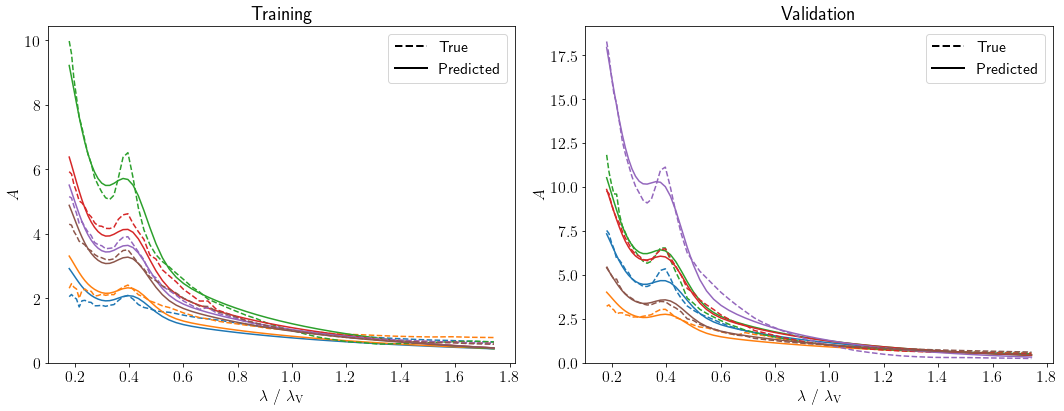

In [30]:
# ini_file = 'conf/iob_0.ini'; ilen = None
# ini_file = 'conf/iob_1.ini'; ilen = None
# ini_file = 'conf/iob_2.ini'; ilen = 30
# ini_file = 'conf/iob_3.ini'; ilen = None
# ini_file = 'conf/iob_4.ini'; ilen = None
# ini_file = 'conf/iob_5.ini'; ilen = None
# ini_file = 'conf/iob_6.ini'; ilen = None
ini_file = 'conf/iob_7.ini'; ilen = None
# processing_fun.plot_pareto(ini_file, ilen=ilen)
# processing_fun.prediction_plots(ini_file, ilen=ilen);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6);

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(15000, 9) (10000, 9)


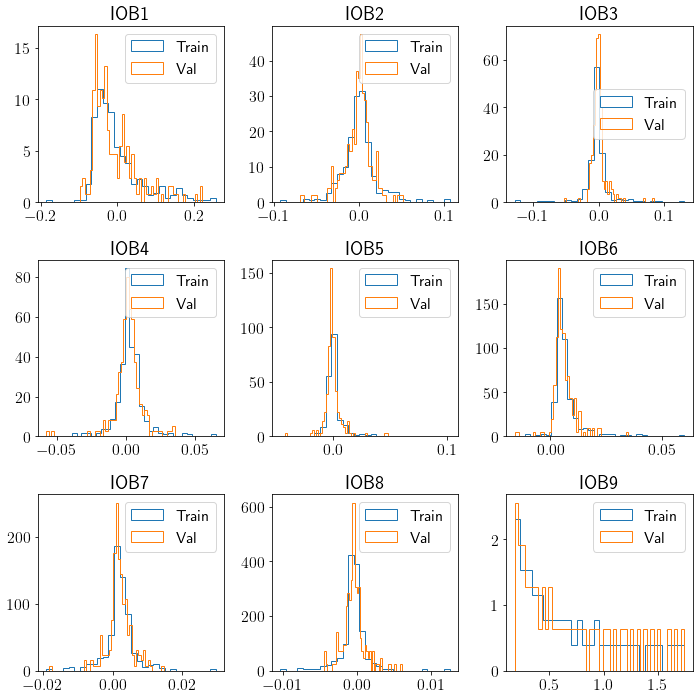

In [17]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()